### Importing necessary libraries

In [1]:
# import torch and some of its submodules
import torch
from torch import nn

# import torchvision and some of its submodules
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# import matplotlib for plotting
import matplotlib.pyplot as plt

In [2]:
# print version of torch and torchvision
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

torch version: 2.7.1+cu118
torchvision version: 0.22.1+cu118


### Getting a dataset (FashionMNIST Dataset)

In [3]:
# dataset used is FashionMNIST

# set up training data
train_data = datasets.FashionMNIST(
    root="data", # where to download the data 
    train=True, # training data
    download=True, # download the data
    transform=ToTensor(), # how to transform the data
    target_transform=None, # how to transform the labels
)

# set up test data
test_data = datasets.FashionMNIST(
    root="data", # where to download the data 
    train=False, # test data
    download=True, # download the data
    transform=ToTensor(), # how to transform the data
    target_transform=None, # how to transform the labels
)

### Checking number of samples in train and test data

In [4]:
# checking number of samples in training and test data
print(f"Number of samples in training data: {len(train_data)}")
print(f"Number of samples in test data: {len(test_data)}")

Number of samples in training data: 60000
Number of samples in test data: 10000


### Checking the shape of train and test images

In [5]:
# checking the first sample of training data
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Image pixels: \n{image[:10, :10]}") # print the first 10x10 pixels of the image

Image shape: torch.Size([1, 28, 28])
Label: 9
Image pixels: 
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.05

In [6]:
# checking image shapes of training and test data
print(f"Image shape of training data: {train_data[0][0].shape} -> (color_channels, height, width)")
print(f"Image shape of test data: {test_data[0][0].shape} -> (color_channels, height, width)")

Image shape of training data: torch.Size([1, 28, 28]) -> (color_channels, height, width)
Image shape of test data: torch.Size([1, 28, 28]) -> (color_channels, height, width)


### Checking the names of classes and their indices

In [7]:
# unique labels in the training data
class_names = train_data.classes
print(f"Unique labels in training data: \n{class_names}")

# index of the labels
idx = train_data.class_to_idx
print(f"Index of the labels: \n{idx.values()}")

Unique labels in training data: 
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Index of the labels: 
dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])


### Plotting first 10 training images

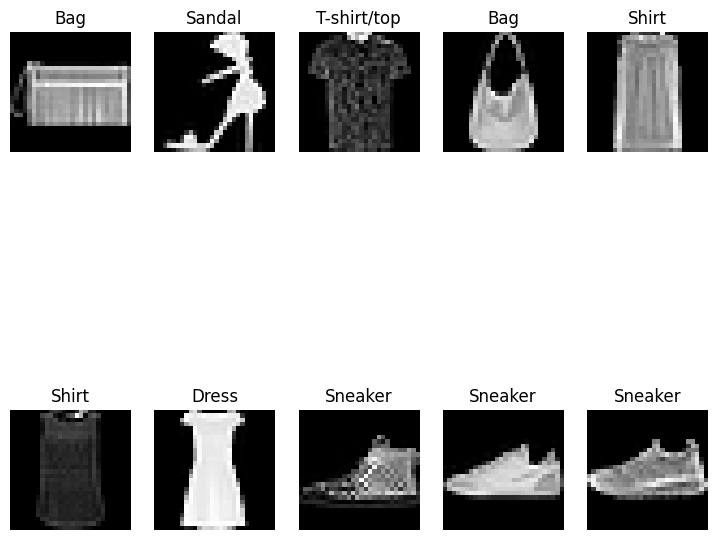

In [8]:
# plotting 10 images of the training data
figure = plt.figure(figsize=(9, 9))
cols, rows = 5, 2
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(class_names[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Plotting just the first image

Image shape: torch.Size([1, 28, 28])
Index and name of the label: 9 -> Ankle boot


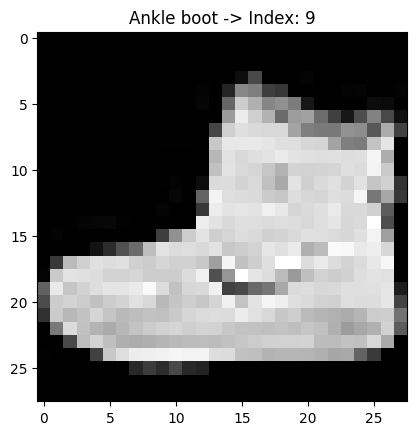

In [9]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Index and name of the label: {label} -> {class_names[label]}")
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"{class_names[label]} -> Index: {label}")
plt.show()

### Prepare the DataLoader
DataLoader converts a pytorch tensor into a python obejct (iterable)

In [10]:
from torch.utils.data import DataLoader

# set an appropriate batch size
BATCH_SIZE = 32

# create a DataLoader for the training data and test data
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# printing the dataloaders
print(f"Dataloader for training data: {train_dataloader}")
print(f"Dataloader for test data: {test_dataloader}\n")

# checking the batch size and length of the dataloaders
print(f"Batch size of training dataloader: {train_dataloader.batch_size}")
print(f"Batch size of test dataloader: {test_dataloader.batch_size}\n")

# length of the dataloaders (number of batches)
print(f"Length of training dataloader: {len(train_dataloader)}")
print(f"Length of test dataloader: {len(test_dataloader)}")

Dataloader for training data: <torch.utils.data.dataloader.DataLoader object at 0x000002AA0058D150>
Dataloader for test data: <torch.utils.data.dataloader.DataLoader object at 0x000002AA4E7FFD10>

Batch size of training dataloader: 32
Batch size of test dataloader: 32

Length of training dataloader: 1875
Length of test dataloader: 313


In [11]:
# check out what's inside the training dataloader
train_batch_features, train_batch_labels = next(iter(train_dataloader))
print(f"{train_batch_features.shape} -> (batch_size, color_channels, height, width)")

torch.Size([32, 1, 28, 28]) -> (batch_size, color_channels, height, width)


Image Size: torch.Size([1, 28, 28])
Label: 4, label size: torch.Size([])


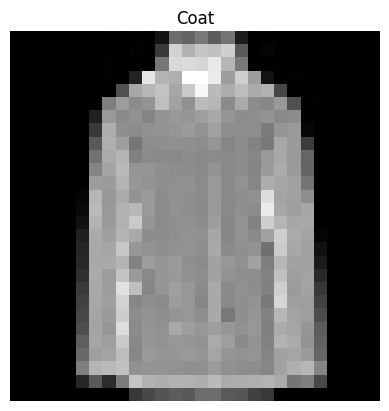

In [12]:
# Show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_batch_features), size=[1]).item()
img, label = train_batch_features[random_idx], train_batch_labels[random_idx]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f"Image Size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

### Build a baseline model `model_0`

In [13]:
# create a flatten layer
flatten_model = nn.Flatten()

# get a single sample
x = train_batch_features[0]

# flatten the sample
output = flatten_model(x) # perform forward pass

# printing what happened
print(f"Shape before flattening: {x.shape} -> (color_channels, height, width)")
print(f"Shape after flattening: {output.shape} -> (color_channels, height * width)")

Shape before flattening: torch.Size([1, 28, 28]) -> (color_channels, height, width)
Shape after flattening: torch.Size([1, 784]) -> (color_channels, height * width)


In [14]:
class FashionMNIST(nn.Module):
    def __init__(self, input_shape:int,
                 hidden_units:int,
                 output_shape:int):
        super().__init__()
        
        self.layer_stack = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    
    def forward(self, x):
        return self.layer_stack(x)

In [15]:
torch.manual_seed(42)

model_0 = FashionMNIST(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
).to('cpu')

model_0

FashionMNIST(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [16]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

### Setup a loss function and an optimizer

In [17]:
import requests
from pathlib import Path

# download helper functions.py file
if Path("helper_functions.py").is_file():
    print("File already exists, skipping download")

else:
    print("Downloading helper_functions.py")
    request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

File already exists, skipping download


In [18]:
# import accuracy metric
from helper_functions import accuracy_fn

# setup loss function & optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

### Create a function to time the experiments

In [19]:
from timeit import default_timer as timer
def print_train_time(start:float, end:float, device:torch.device=None):
    """ Prints difference between start and end time."""
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

### Build a training and testing loop

In [21]:
from tqdm.auto import tqdm

# set the seed and start timer
torch.manual_seed(42)
start_time = timer()

# set number of epochs
epochs = 3

# create a training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"-------------------------Epoch: {epoch}--------------------------\n")
    
    # TRAINING
    train_loss = 0
    
    # add a loop to loop through the training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        
        # 1. forward pass
        y_pred = model_0(X)
        
        # 2. calculate the loss (per)
        loss = loss_fn(y_pred, y)
        train_loss += loss # accumulate the train loss
        
        # 3. optimizer zer grad
        optimizer.zero_grad()
        
        # 4. loss backward
        loss.backward()
        
        # 5. optimzer step...
        optimizer.step()
        
        # print what's happening
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    # Divide the total train loss by the length of the dataloader
    train_loss /= len(train_dataloader)
    
    # TESTING
    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            # 1. forward pass
            test_pred = model_0(X_test)
            
            # 2. calcualte the loss
            test_loss += loss_fn(test_pred, y_test)
            
            # 3. calculate accuracy
            test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
        
        # Calculate the test loss (average per batch)
        test_loss /= len(test_dataloader)
        
        # Calculate the test accuracy (average per batch)
        test_acc /= len(test_dataloader)
    
    # Print what's happening
    print(f"\nTrain Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Test ACcuracy: {test_acc:.2f}")

# Calculate the training time
end_time = timer()
total_train_time = print_train_time(start=start_time, end=end_time, device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

-------------------------Epoch: 0--------------------------

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 1/3 [00:10<00:21, 10.80s/it]


Train Loss: 0.5904 | Test Loss: 0.5095 | Test ACcuracy: 82.04
-------------------------Epoch: 1--------------------------

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 67%|██████▋   | 2/3 [00:23<00:12, 12.08s/it]


Train Loss: 0.4763 | Test Loss: 0.4799 | Test ACcuracy: 83.20
-------------------------Epoch: 2--------------------------

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 3/3 [00:35<00:00, 11.68s/it]


Train Loss: 0.4550 | Test Loss: 0.4766 | Test ACcuracy: 83.43
Train time on cpu: 35.052 seconds
